In this notebook we explore more about eye tracking data analysis

In [48]:
# Derived from:
#     https://www.axonlab.org/hcph-sops/data-management/eyetrack-qc
# Load the autoreload extension
%load_ext autoreload
# Set autoreload to update the modules every time before executing a new line of code
%autoreload 2

%matplotlib inline
from pathlib import Path
import shutil
import json
import ppjson
from importlib import reload  # For debugging purposes

import numpy as np
import pandas as pd
import scipy.io as sio

import eyetrackingrun as et

from IPython.display import HTML
from matplotlib import animation
from matplotlib.animation import FuncAnimation, PillowWriter
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import copy
from write_bids_yiwei import EyeTrackingRun, write_bids, write_bids_from_df



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# S2 Stable Mask QA Version

This copy keeps the original S2 visualization flow, but makes the stable-region mask path safer.

- T1/T2 duration is inferred from the filename instead of manually hardcoded.
- Offset is validated before mask padding.
- Screen center is derived from `ScreenAOIDefinition`; physical screen size remains an explicit local assumption.
- Mask output is saved as `uint8` plus a JSON sidecar with threshold and preserved-ratio metadata.


In [ ]:
from ipyfilechooser import FileChooser
from IPython.display import display

DEFAULT_DATA_ROOT = Path("/Volumes/FS_PROJETS/MatTechLab/yiwei.jia/datasets/")

# If the widget does not respond after reopening the notebook, paste a full .tsv.gz path here.
# Example: MANUAL_TSV_PATH = "/Users/cag/Documents/Dataset/temp/example.tsv.gz"
MANUAL_TSV_PATH = ""

if not DEFAULT_DATA_ROOT.exists():
    print(f"Warning: default data root is not mounted/found: {DEFAULT_DATA_ROOT}")

fc = FileChooser(str(DEFAULT_DATA_ROOT))
fc.title = "Select .tsv.gz eye-tracking file"
fc.show_only_dirs = False
fc.filter_pattern = ["*.tsv.gz"]

display(fc)
print("If the chooser does not work, set MANUAL_TSV_PATH above and rerun this cell plus the next cell.")


In [ ]:
import re

if MANUAL_TSV_PATH:
    selected_path = Path(MANUAL_TSV_PATH).expanduser().resolve()
else:
    if not getattr(fc, "selected", None):
        raise RuntimeError(
            "No file selected. Use the FileChooser, or paste a full .tsv.gz path into MANUAL_TSV_PATH "
            "in the previous cell and rerun."
        )
    selected_path = Path(fc.selected).expanduser().resolve()

print("Selected:", selected_path)
if not selected_path.exists():
    raise FileNotFoundError(f"Selected TSV does not exist: {selected_path}")
if not selected_path.name.endswith(".tsv.gz"):
    raise ValueError(f"Expected a .tsv.gz file, got: {selected_path.name}")

RECON_FOLDER_DATE = selected_path.parent.name
tsv_name = selected_path.name
FILE_NAME = tsv_name[:-len(".tsv.gz")]

# -------- subject_idx (MIDxxxxx) --------
match = re.match(r"(MID\d+)_", FILE_NAME)
if not match:
    raise ValueError("Could not extract subject_idx from filename")
subject_idx = match.group(1)

# -------- T_idx / mode inferred from filename --------
t_match = re.search(r"(^|[_\-.])T([12])(?:weighted)?(?=[_\-.]|$)", FILE_NAME, flags=re.IGNORECASE)
if not t_match:
    raise ValueError(f"Could not extract T_idx from filename: {FILE_NAME}")
T_idx = int(t_match.group(2))
mode = "T1" if T_idx == 1 else "T2"

TWIX_BY_TIDX = {
    1: 371817.0,
    2: 646617.5,
}

# -------- results --------
print("subject_idx       =", subject_idx)
print("RECON_FOLDER_DATE =", RECON_FOLDER_DATE)
print("FILE_NAME         =", FILE_NAME)
print("tsv_name          =", tsv_name)
print("T_idx             =", T_idx)
print("mode              =", mode)


In [51]:
BIDS_PATH = selected_path.parent

recording_file_src = BIDS_PATH / tsv_name
print(f'recording_file: {recording_file_src}')
metadata_file_src = recording_file_src.parent / recording_file_src.name.replace(".tsv.gz", ".json")
print(f'metadata_file: {metadata_file_src}')


recording_file: /Volumes/FS_PROJETS/MatTechLab/yiwei.jia/datasets/0044/MID44240_fixation_dots_T1weighted_2026-06-02_14h44.39.975.tsv.gz
metadata_file: /Volumes/FS_PROJETS/MatTechLab/yiwei.jia/datasets/0044/MID44240_fixation_dots_T1weighted_2026-06-02_14h44.39.975.json


In [52]:
# Destination base folder
dest_dir = Path("/Users/cag/Documents/Dataset/recon_results/" + RECON_FOLDER_DATE)

# Create destination directory if needed
dest_dir.mkdir(parents=True, exist_ok=True)
for src in (recording_file_src, metadata_file_src):
    if not src.exists():
        raise FileNotFoundError(f"Source file not found: {src}")

    dst = dest_dir / src.name
    shutil.copy2(src, dst)   # copy2 preserves metadata

    print(f"Copied: {src} → {dst}")

recording_file = dest_dir / recording_file_src.name
metadata_file  = dest_dir / metadata_file_src.name

print("New recording_file:", recording_file)
print("New metadata_file :", metadata_file)

Copied: /Volumes/FS_PROJETS/MatTechLab/yiwei.jia/datasets/0044/MID44240_fixation_dots_T1weighted_2026-06-02_14h44.39.975.tsv.gz → /Users/cag/Documents/Dataset/recon_results/0044/MID44240_fixation_dots_T1weighted_2026-06-02_14h44.39.975.tsv.gz
Copied: /Volumes/FS_PROJETS/MatTechLab/yiwei.jia/datasets/0044/MID44240_fixation_dots_T1weighted_2026-06-02_14h44.39.975.json → /Users/cag/Documents/Dataset/recon_results/0044/MID44240_fixation_dots_T1weighted_2026-06-02_14h44.39.975.json
New recording_file: /Users/cag/Documents/Dataset/recon_results/0044/MID44240_fixation_dots_T1weighted_2026-06-02_14h44.39.975.tsv.gz
New metadata_file : /Users/cag/Documents/Dataset/recon_results/0044/MID44240_fixation_dots_T1weighted_2026-06-02_14h44.39.975.json


In [9]:
metadata = json.loads(metadata_file.read_text())

def read_et_recording(input_file, metadata):
    recording = pd.read_csv(input_file, sep="	", na_values="n/a")
    columns = metadata.get("Columns")

    if "timestamp" not in recording.columns and isinstance(columns, list):
        fallback = pd.read_csv(input_file, sep="	", na_values="n/a", header=None)
        if len(fallback.columns) == len(columns):
            fallback.columns = [str(column) for column in columns]
            return fallback, "headerless_with_metadata_columns"

    unnamed_columns = [column for column in recording.columns if str(column).startswith("Unnamed:")]
    if unnamed_columns:
        recording = recording.drop(columns=unnamed_columns)
        return recording, "headered_with_legacy_index_column"

    return recording, "headered"

recording, input_format = read_et_recording(recording_file, metadata)
recording.head()
print(f'recording len: {len(recording)}')
print(f'Input TSV format detected: {input_format}')
# print(f'meta_data: {metadata}')

print('The information from matlab / protocol table:')
twix_duration = TWIX_BY_TIDX[T_idx]
print(f'here the duration of the rawdata is: {twix_duration} ms')
# mri_duration = first-trigger offset + ET-derived mask duration
mri_start_first_trigger = 0  # ms; override only if log.txt indicates MRI starts before first trigger
print(f'The MRI_start -> the first trigger:    {mri_start_first_trigger} ms')


recording len: 621505
Input TSV format detected: headered_with_legacy_index_column
The information from matlab / protocol table:
here the duration of the rawdata is: 371817.0 ms
The MRI_start -> the first trigger:    0 ms


# 1 Metadata and calibration

We always run a calibration before it is started. As a result, we will typically see the metadata corresponding to calibration on this particular run.

Now, let's print out the contents of the BIDS' sidecar JSON corresponding to the DWI in this session.

In [53]:
target_message = '!MODE RECORD CR 1000 2 0 R'
backup_start_message = 'ELCLCFG TOWER'
trigger_message = 'Key s trigger response'

def get_start_timestamp(metadata):
    if metadata.get("StartTimestamp") is not None:
        return int(metadata["StartTimestamp"]), "StartTimestamp"

    for stamp, msg in metadata.get('LoggedMessages', []):
        if msg in {target_message, backup_start_message}:
            return int(stamp), f"LoggedMessages:{msg}"

    # Older S1 notebooks stored the raw EyeLink timestamp in StartTime.
    if metadata.get("StartTime") is not None:
        return int(metadata["StartTime"]), "legacy StartTime"

    raise RuntimeError("Could not find ET start timestamp in metadata")

def get_trigger_timestamp(metadata):
    for index, element in enumerate(metadata.get('LoggedMessages', [])):
        if element[1] == trigger_message:
            print(f"First Trigger occurrence is at index {index}: {element}")
            print(f"at timestamp {element[0]}")
            return int(element[0])
    raise RuntimeError("Could not find MRI trigger message in LoggedMessages")

start_timestamp, start_timestamp_source = get_start_timestamp(metadata)
trigger_timestamp = get_trigger_timestamp(metadata)

print(f"Timestamp to start recording: {start_timestamp} ({start_timestamp_source})")

gap_start_dot = start_timestamp - trigger_timestamp
print(f'From the trigger arrival to the start of recording: {gap_start_dot}')


First Trigger occurrence is at index 1: [2407574, 'Key s trigger response']
at timestamp 2407574
Timestamp to start recording: 2407588 (StartTimestamp)
From the trigger arrival to the start of recording: 14


In [54]:
print(recording[0:100])


    x_coordinate  y_coordinate  pupil_size  eye1_pupil_x_coordinate  \
0            NaN           NaN         NaN                 -32768.0   
1            NaN           NaN         NaN                 -32768.0   
2            NaN           NaN         NaN                 -32768.0   
3            NaN           NaN         NaN                 -32768.0   
4            NaN           NaN         NaN                 -32768.0   
..           ...           ...         ...                      ...   
95    385.899994    289.200012      1378.0                  -3771.0   
96    385.799988    293.100006      1367.0                  -3772.0   
97    385.899994    297.000000      1356.0                  -3772.0   
98    385.799988    299.299988      1344.0                  -3773.0   
99    385.000000    299.799988      1343.0                  -3780.0   

    eye1_pupil_y_coordinate  eye1_href_x_coordinate  eye1_href_y_coordinate  \
0                  -32768.0                 -7936.0                 

In [55]:
t_axis = (
    recording.timestamp.values - recording.timestamp[0]
) / metadata["SamplingFrequency"]*1000
print(f"The end of the timestamp: {t_axis[-1]}")

The end of the timestamp: 621504.0


In [56]:
print(metadata["Columns"])
recording = recording.rename(
        columns={
            f"eye1_pupil_size": f"pupil_size",
            f"eye1_fixation": f"fixation",
            f"eye1_saccade": f"saccade",
            f"eye1_blink": f"blink",
            f"eye1_x_coordinate": f"x_coordinate", 
            f"eye1_y_coordinate": f"y_coordinate"         
        }
    )

metadata["Columns"] = recording.columns.tolist()
print(metadata["Columns"])

def summarize_s2_input(recording, metadata, input_format):
    timestamp = recording["timestamp"] if "timestamp" in recording.columns else pd.Series(dtype=float)
    coordinate_columns = [column for column in ("x_coordinate", "y_coordinate") if column in recording.columns]
    event_columns = [column for column in ("fixation", "saccade", "blink") if column in recording.columns]
    return {
        "input_format": input_format,
        "sample_count": int(len(recording)),
        "metadata_columns_count": len(metadata.get("Columns", [])) if isinstance(metadata.get("Columns"), list) else None,
        "timestamp_start": int(timestamp.iloc[0]) if not timestamp.empty else None,
        "timestamp_end": int(timestamp.iloc[-1]) if not timestamp.empty else None,
        "timestamp_monotonic_increasing": bool(timestamp.is_monotonic_increasing) if not timestamp.empty else False,
        "duplicate_timestamps": int(timestamp.duplicated().sum()) if not timestamp.empty else 0,
        "coordinate_nan_ratio": {column: float(recording[column].isna().mean()) for column in coordinate_columns},
        "event_coverage_ratio": {column: float(recording[column].fillna(0).astype(bool).mean()) for column in event_columns},
        "sampling_frequency": metadata.get("SamplingFrequency"),
    }

s2_input_sanity = summarize_s2_input(recording, metadata, input_format)
print("S2 input sanity summary:")
print(json.dumps(s2_input_sanity, indent=2, sort_keys=True))


['x_coordinate', 'y_coordinate', 'pupil_size', 'eye1_pupil_x_coordinate', 'eye1_pupil_y_coordinate', 'eye1_href_x_coordinate', 'eye1_href_y_coordinate', 'eye1_x_velocity', 'eye1_href_x_velocity', 'eye1_raw_x_velocity', 'fast_href_x_velocity', 'fast_raw_x_velocity', 'screen_ppdeg_x_coordinate', 'screen_ppdeg_y_coordinate', 'timestamp', 'fixation', 'saccade', 'blink']
['x_coordinate', 'y_coordinate', 'pupil_size', 'eye1_pupil_x_coordinate', 'eye1_pupil_y_coordinate', 'eye1_href_x_coordinate', 'eye1_href_y_coordinate', 'eye1_x_velocity', 'eye1_href_x_velocity', 'eye1_raw_x_velocity', 'fast_href_x_velocity', 'fast_raw_x_velocity', 'screen_ppdeg_x_coordinate', 'screen_ppdeg_y_coordinate', 'timestamp', 'fixation', 'saccade', 'blink']
S2 input sanity summary:
{
  "coordinate_nan_ratio": {
    "x_coordinate": 0.04473173988946187,
    "y_coordinate": 0.04640027031158237
  },
  "duplicate_timestamps": 0,
  "event_coverage_ratio": {
    "blink": 0.07685054826590293,
    "fixation": 0.905500358001

In [57]:
recording.columns

Index(['x_coordinate', 'y_coordinate', 'pupil_size', 'eye1_pupil_x_coordinate',
       'eye1_pupil_y_coordinate', 'eye1_href_x_coordinate',
       'eye1_href_y_coordinate', 'eye1_x_velocity', 'eye1_href_x_velocity',
       'eye1_raw_x_velocity', 'fast_href_x_velocity', 'fast_raw_x_velocity',
       'screen_ppdeg_x_coordinate', 'screen_ppdeg_y_coordinate', 'timestamp',
       'fixation', 'saccade', 'blink'],
      dtype='object')

In [58]:
# See cleaned cell 4

In [59]:
plot_pupil_saccade = False

if plot_pupil_saccade:
    fig = plt.figure(figsize=(16, 2))

    plt.plot(
        t_axis,
        recording["pupil_size"].values,
    )

    plt.plot(
        t_axis,
        recording["saccade"].values * 5000,
    )

    plt.xlabel("time [s]")
    plt.ylabel("pupil area [a.u.]")
    plt.xlim((200, 220))
    plt.title('Pupil area and saccading')
    print(f'At this time, since blinking is detected, we cannot get clear pupil area ?')

In [60]:
plot_x_saccade = False
if plot_x_saccade:
    fig = plt.figure(figsize=(16, 2))
    plt.plot(
        t_axis,
        recording["x_coordinate"].values,
    )

    plt.plot(
        t_axis,
        recording["saccade"].values * 1000,
    )
    plt.xlim((200, 220))

Check fixation

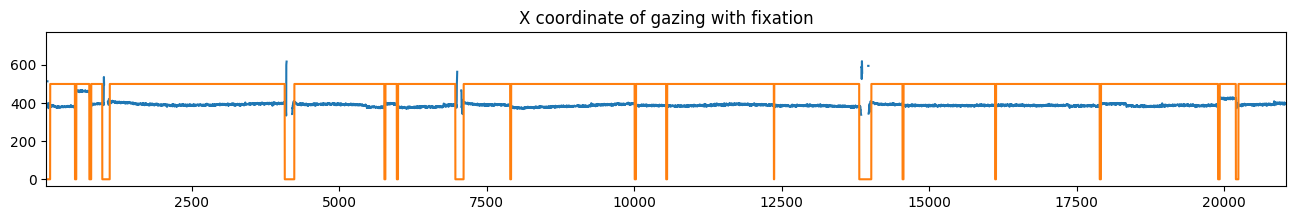

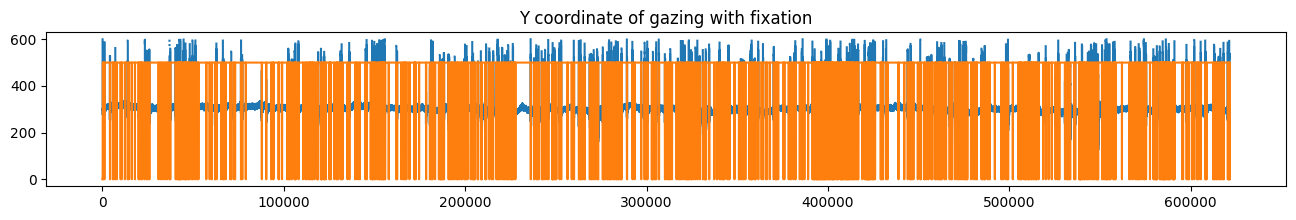

In [61]:
plot_fixation = True
if plot_fixation:
    # Fixation
    fig = plt.figure(figsize=(16, 2))
    plt.plot(
        t_axis,
        recording["x_coordinate"].values,
    )

    plt.plot(
        t_axis,
        recording["fixation"].values * 500,
    )
    plt.xlim((30, 21050))
    plt.title('X coordinate of gazing with fixation')

    fig = plt.figure(figsize=(16, 2))
    plt.plot(
        t_axis,
        recording["y_coordinate"].values,
    )

    plt.plot(
        t_axis,
        recording["fixation"].values * 500,
    )
    # plt.xlim((5000, 10000))
    plt.title('Y coordinate of gazing with fixation')
    

The analysis did not reveal a strong correlation between pupil size and saccade or fixation events.

The coordinate sequence is stable during fixation, we should extract the data in the event.

# 2 Data Cleaning

- Seperate the two phases of sequences
- Extract the X Y coordinates
- Eliminate the blinking and non-fixation area of LIBRE data, and keep the raw data of STANDARD.Because there is no mechanism for the second STANDARD one to correct the eye fixation.
- Design some criteria for cleaning the noise data
    - Visual angle
    - Heat maps
    - Fixation algorithm (literature review)

## 2.1 Seperate the two phases of sequences

In [62]:
# -----------------------------
reset_index_bool = False
eliminate_all_nan = False
eliminate_first_nan = False
# -----------------------------

size = (
    metadata["ScreenAOIDefinition"][1][1],
    metadata["ScreenAOIDefinition"][1][3],
)

coor_data = recording[["x_coordinate", "y_coordinate"]]
print(f"Extract X Y coordinates from recording: {len(coor_data)}")

if eliminate_all_nan:
    coor_data = coor_data[coor_data.x_coordinate.notna() & coor_data.y_coordinate.notna()]
    coor_recording = recording[recording.x_coordinate.notna() & recording.y_coordinate.notna()]
elif eliminate_first_nan:
    # Find the first non-NaN row
    first_valid_index = coor_data[['x_coordinate', 'y_coordinate']].dropna(how='all').index[0]

    # Slice the DataFrame from the first non-NaN row onward
    coor_data = coor_data.iloc[first_valid_index:]
    
    coor_recording = recording.iloc[first_valid_index:]
    
else:
    coor_recording = recording

if reset_index_bool:
    coor_data.reset_index(drop=True, inplace=True)
    coor_recording.reset_index(drop=True, inplace=True)

print(metadata["ScreenAOIDefinition"]) 
print(coor_data)
print(f"Eliminating nan values? {eliminate_first_nan}: {len(coor_data)}")
print(f'len of coor_data {len(coor_data)} should be equal to len of coor_recording {len(coor_recording)}')

Extract X Y coordinates from recording: 621505
['square', [0, 800, 0, 600]]
        x_coordinate  y_coordinate
0                NaN           NaN
1                NaN           NaN
2                NaN           NaN
3                NaN           NaN
4                NaN           NaN
...              ...           ...
621500    449.100006    290.500000
621501    449.500000    290.899994
621502    449.500000    290.799988
621503    449.700012    290.399994
621504    450.100006    290.000000

[621505 rows x 2 columns]
Eliminating nan values? False: 621505
len of coor_data 621505 should be equal to len of coor_recording 621505


In [63]:
# Duration setting according to the raw data info.
# Unit convention: EyeLink timestamps and twix_duration are in ms; SamplingFrequency is Hz.

offset = int(np.round(mri_start_first_trigger + gap_start_dot))
if offset < 0:
    raise ValueError(f"Negative offset is not valid for mask padding: {offset}")
if offset > int(np.round(twix_duration)):
    raise ValueError(f"Offset {offset} exceeds twix_duration {twix_duration}")

sampling_frequency = metadata["SamplingFrequency"]
libre_duration_ms = twix_duration - offset
libre_duration_sec = libre_duration_ms / sampling_frequency
libre_samples = int(np.ceil(libre_duration_ms / sampling_frequency * sampling_frequency))

print(f"mode: {mode}")
print(f"offset before ET recording: {offset} ms")
print(f"The length of ET recording we need for {mode} LIBRE {subject_idx}: {libre_duration_sec} sec")
print(f"The number of ET samples selected for {mode} LIBRE: {libre_samples}")


mode: T1
offset before ET recording: 14 ms
The length of ET recording we need for T1 LIBRE MID44240: 371.803 sec
The number of ET samples selected for T1 LIBRE: 371803


mode: T1
set start margin as 0
371803


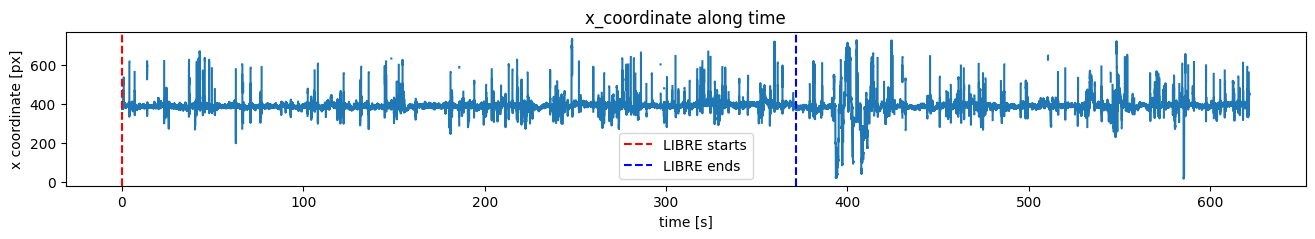

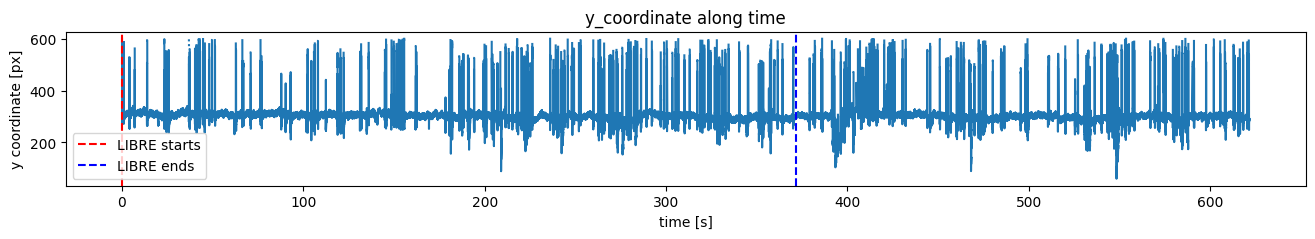

In [64]:
start_margin = 0
print(f'mode: {mode}')
print(f"set start margin as {start_margin}")

if libre_samples <= 0:
    raise ValueError(f"No LIBRE samples selected: libre_samples={libre_samples}")
if libre_samples + start_margin > len(coor_data):
    raise ValueError(
        f"Requested {libre_samples + start_margin} samples, but only {len(coor_data)} ET samples are available."
    )

libre_end_sample = int(libre_samples) + start_margin

t_axis_xy = coor_data.index / metadata["SamplingFrequency"]

# x coordinate
fig = plt.figure(figsize=(16, 2))
plt.plot(t_axis_xy, coor_data["x_coordinate"].values)
plt.axvline(x=start_margin / metadata["SamplingFrequency"], color='r', linestyle='--', label='LIBRE starts')
plt.axvline(x=libre_end_sample / metadata["SamplingFrequency"], color='b', linestyle='--', label='LIBRE ends')
plt.title("x_coordinate along time")
plt.xlabel("time [s]")
plt.ylabel("x coordinate [px]")
plt.legend()

# y coordinate
fig = plt.figure(figsize=(16, 2))
plt.plot(t_axis_xy, coor_data["y_coordinate"].values)
plt.axvline(x=start_margin / metadata["SamplingFrequency"], color='r', linestyle='--', label='LIBRE starts')
plt.axvline(x=libre_end_sample / metadata["SamplingFrequency"], color='b', linestyle='--', label='LIBRE ends')
plt.title("y_coordinate along time")
plt.xlabel("time [s]")
plt.ylabel("y coordinate [px]")
plt.legend()

coor_data_LIBRE = coor_data.iloc[start_margin:libre_end_sample].copy()
coor_recording_LIBRE = coor_recording.iloc[start_margin:libre_end_sample].copy()
coor_data_LIBRE_raw = copy.deepcopy(coor_data_LIBRE)
print(len(coor_data_LIBRE))


In [65]:
# import scipy.io
# coor_array = coor_data_LIBRE[['x_coordinate', 'y_coordinate']].to_numpy()
# scipy.io.savemat(f'coor_data_raw_t1w_libre_sub00{subject_idx}.mat', {'coordinates': coor_array})

## 2.2 Eliminating blinking

In [66]:
use_eliminate_blink = True

def eliminate_blink(coor_data, coor_recording, seq_name):
#     coor_data = coor_data[coor_recording.blink < 1]
#     coor_recording = coor_recording[coor_recording.blink < 1]
# Note: instead of filtering them out, I assign nan to the invalid elements
    print(f'The data will be eliminated: {len(coor_data[coor_recording.blink > 0])}')
    coor_data.loc[coor_recording.blink > 0,  ['x_coordinate', 'y_coordinate']] = np.nan
    coor_recording.loc[coor_recording.blink > 0,  ['x_coordinate', 'y_coordinate']] = np.nan
    print(f'After eliminating blinking: \nlen of coor_data_{seq_name} {len(coor_data)} \
      should be equal to len of coor_recording {len(coor_recording)}')
    return coor_data, coor_recording


if use_eliminate_blink:
    coor_data_LIBRE,  coor_recording_LIBRE = eliminate_blink(coor_data_LIBRE, coor_recording_LIBRE, 'LIBRE')
# coor_data_STANDARD,  coor_recording_STANDARD = eliminate_blink(coor_data_STANDARD, 
#                                                                coor_recording_STANDARD, 'STANDARD')
plot_heatmap = False
if plot_heatmap:
    import plot
    plot.plot_heatmap_coordinate(coor_data_LIBRE, density=False, screen_size=size, 
                                 title='LIBRE: The gaze from the beginning to the end')
    plot.plot_heatmap_coordinate(coor_data_STANDARD, density=False, screen_size=size, 
                                 title='STANDARD: The gaze from the beginning to the end')

The data will be eliminated: 26087
After eliminating blinking: 
len of coor_data_LIBRE 371803       should be equal to len of coor_recording 371803


In [26]:
# coor_data_LIBRE[coor_recording_LIBRE.blink > 0]

## 2.3 Preserving fixation

In [67]:
use_preserve_fixation = True

def preserve_fixation(coor_data, coor_recording, seq_name):
#     coor_data = coor_data[coor_recording.fixation > 0]
#     coor_recording = coor_recording[coor_recording.fixation > 0]
    print(f'The data will be eliminated: {len(coor_data[coor_recording.fixation < 1])}')
    coor_data.loc[coor_recording.fixation < 1, ['x_coordinate', 'y_coordinate']] = np.nan
    coor_recording.loc[coor_recording.fixation < 1, ['x_coordinate', 'y_coordinate']] = np.nan

    print(f'After preserving fixation: \nlen of coor_data_{seq_name} {len(coor_data)} \
      should be equal to len of coor_recording {len(coor_recording)}')
    return coor_data, coor_recording


if use_preserve_fixation:
    coor_data_LIBRE,  coor_recording_LIBRE = preserve_fixation(coor_data_LIBRE, coor_recording_LIBRE, 'LIBRE')
    # coor_data_STANDARD,  coor_recording_STANDARD = preserve_fixation(coor_data_STANDARD, 
    #                                                                coor_recording_STANDARD, 'STANDARD')
plot_heatmap = False
if plot_heatmap:
    import plot
    plot.plot_heatmap_coordinate(coor_data_LIBRE, density=False, screen_size=size, 
                                 title='LIBRE: The gaze from the beginning to the end')
    plot.plot_heatmap_coordinate(coor_data_STANDARD, density=False, screen_size=size, 
                                 title='STANDARD: The gaze from the beginning to the end')

The data will be eliminated: 31903
After preserving fixation: 
len of coor_data_LIBRE 371803       should be equal to len of coor_recording 371803


## Event Mask Overlap Analysis

Check whether `non-fixation` is mostly explained by saccades/blinks, and flag suspicious event overlaps before the stable-region mask is generated.


In [ ]:
def analyze_event_mask_overlap(coor_recording):
    required = ["fixation", "saccade", "blink"]
    missing = [column for column in required if column not in coor_recording.columns]
    if missing:
        raise KeyError(f"Missing event columns for overlap analysis: {missing}")

    fixation = coor_recording["fixation"].fillna(0).astype(bool).to_numpy()
    saccade = coor_recording["saccade"].fillna(0).astype(bool).to_numpy()
    blink = coor_recording["blink"].fillna(0).astype(bool).to_numpy()
    non_fixation = ~fixation

    n = len(coor_recording)
    nonfix_explained_by_saccade_or_blink = non_fixation & (saccade | blink)
    nonfix_unexplained = non_fixation & ~(saccade | blink)

    counts = {
        "samples": int(n),
        "fixation": int(fixation.sum()),
        "non_fixation": int(non_fixation.sum()),
        "saccade": int(saccade.sum()),
        "blink": int(blink.sum()),
        "nonfix_and_saccade": int((non_fixation & saccade).sum()),
        "nonfix_and_blink": int((non_fixation & blink).sum()),
        "saccade_and_blink": int((saccade & blink).sum()),
        "nonfix_explained_by_saccade_or_blink": int(nonfix_explained_by_saccade_or_blink.sum()),
        "nonfix_not_saccade_or_blink": int(nonfix_unexplained.sum()),
        "fixation_and_saccade": int((fixation & saccade).sum()),
        "fixation_and_blink": int((fixation & blink).sum()),
        "fixation_and_saccade_and_blink": int((fixation & saccade & blink).sum()),
    }

    denominators = {
        "all_samples": max(n, 1),
        "non_fixation": max(counts["non_fixation"], 1),
        "saccade": max(counts["saccade"], 1),
        "blink": max(counts["blink"], 1),
    }
    ratios = {
        "nonfix_fraction_of_all": counts["non_fixation"] / denominators["all_samples"],
        "saccade_fraction_of_all": counts["saccade"] / denominators["all_samples"],
        "blink_fraction_of_all": counts["blink"] / denominators["all_samples"],
        "nonfix_explained_by_saccade_or_blink_fraction_of_nonfix": counts["nonfix_explained_by_saccade_or_blink"] / denominators["non_fixation"],
        "nonfix_not_saccade_or_blink_fraction_of_nonfix": counts["nonfix_not_saccade_or_blink"] / denominators["non_fixation"],
        "saccade_overlaps_blink_fraction_of_saccade": counts["saccade_and_blink"] / denominators["saccade"],
        "blink_overlaps_saccade_fraction_of_blink": counts["saccade_and_blink"] / denominators["blink"],
        "fixation_overlaps_saccade_fraction_of_saccade": counts["fixation_and_saccade"] / denominators["saccade"],
        "fixation_overlaps_blink_fraction_of_blink": counts["fixation_and_blink"] / denominators["blink"],
    }

    warnings = []
    if ratios["nonfix_not_saccade_or_blink_fraction_of_nonfix"] > 0.10:
        warnings.append("More than 10% of non-fixation samples are neither saccade nor blink; inspect parser/event labels.")
    if ratios["fixation_overlaps_saccade_fraction_of_saccade"] > 0.05:
        warnings.append("More than 5% of saccade samples overlap fixation; event definitions may not be mutually exclusive.")
    if ratios["fixation_overlaps_blink_fraction_of_blink"] > 0.05:
        warnings.append("More than 5% of blink samples overlap fixation; event definitions may not be mutually exclusive.")

    return {
        "counts": counts,
        "ratios": ratios,
        "warnings": warnings,
    }

# Analyze after blink/non-fixation have been marked as NaN, but event columns are unchanged.
event_overlap_summary = analyze_event_mask_overlap(coor_recording_LIBRE)
print("Event mask overlap summary:")
print(json.dumps(event_overlap_summary, indent=2, sort_keys=True))
for warning in event_overlap_summary["warnings"]:
    print(f"WARNING: {warning}")


## 2.4 Plot the gazing dots

In [68]:
# see cleaned_cell [1]

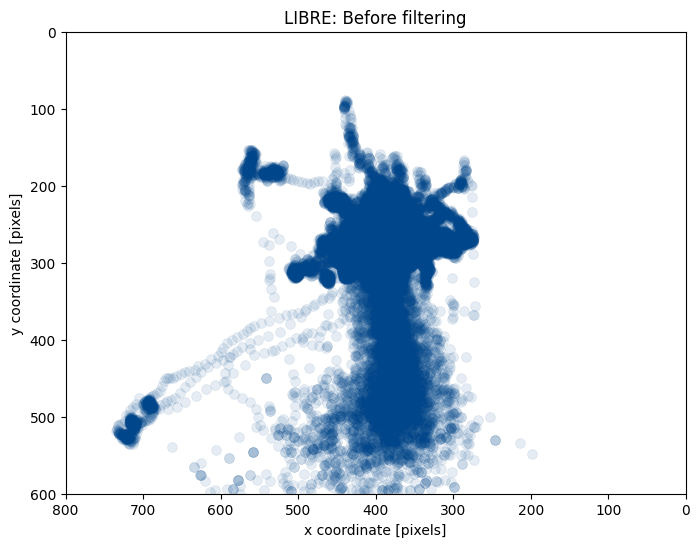

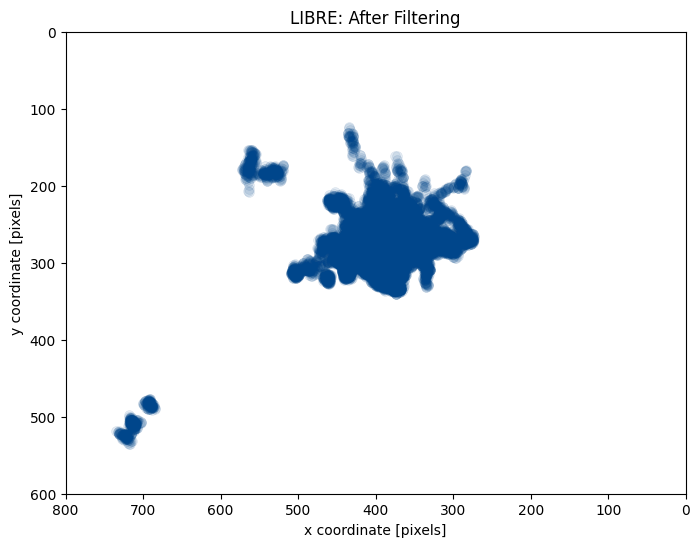

In [69]:
# Example data (replace with your actual data)
X_coord = coor_data_LIBRE_raw['x_coordinate']
Y_coord = coor_data_LIBRE_raw['y_coordinate']
fig, ax= plt.subplots(figsize=(8, 6))
# Plot the data, flipping X coordinates and using dots as markers
plt.scatter(X_coord, Y_coord, s=50, c='#00468b', alpha=0.1, edgecolors='#00468b', linewidth=0.5)
plt.xlim((0, 800))
plt.ylim((0, 600))
# Set plot title
plt.title('LIBRE: Before filtering')
plt.xlabel('x coordinate [pixels]')
plt.ylabel('y coordinate [pixels]')
# Reverse the direction of the Y-axis
plt.gca().invert_yaxis()
plt.gca().invert_xaxis()

# ============================================================
# Example data (replace with your actual data)
X_coord = coor_data_LIBRE['x_coordinate']
Y_coord = coor_data_LIBRE['y_coordinate']
fig, ax= plt.subplots(figsize=(8, 6))
# Plot the data, flipping X coordinates and using dots as markers
plt.scatter(X_coord, Y_coord, s=50, c='#00468b', alpha=0.1, edgecolors='#00468b', linewidth=0.5)
plt.xlim((0, 800))
plt.ylim((0, 600))
# Set plot title
plt.title('LIBRE: After Filtering')
plt.xlabel('x coordinate [pixels]')
plt.ylabel('y coordinate [pixels]')
# Reverse the direction of the Y-axis
plt.gca().invert_yaxis()
plt.gca().invert_xaxis()
# ============================================================



By far, we initially cleaned data based on the inherent properties in the metadata from EyeLink. And we plotted the fixation evaluation. 

In [70]:
# see cleaned_cell [2]

## 2.5 Visualize gaze groups

## 4.4 Event statistics

We also summarize the EyeLink event masks for the current subject. This mirrors the event-duration analysis from the solution notebook: we detect contiguous runs of `blink`, `saccade`, and `fixation`, then compute basic duration statistics for each event type.

In [71]:
def to_builtin(value):
    if isinstance(value, dict):
        return {k: to_builtin(v) for k, v in value.items()}
    if isinstance(value, list):
        return [to_builtin(v) for v in value]
    if isinstance(value, tuple):
        return tuple(to_builtin(v) for v in value)
    if isinstance(value, np.generic):
        return value.item()
    return value


def identify_start_end_event(df, events):
    event_dict = {}
    df = df.reset_index(drop=True).copy()

    for event in events:
        if event not in df.columns:
            raise KeyError(f"Missing event column: {event}")

        event_shift = f"{event}_shift"
        event_change = f"{event}_change"

        df[event_shift] = df[event].shift(1, fill_value=0)
        df[event_change] = df[event] - df[event_shift]

        event_starts = df.index[df[event_change] == 1].tolist()
        event_ends = df.index[df[event_change] == -1].tolist()

        if len(event_starts) > len(event_ends) and int(df[event].iloc[-1]) == 1:
            event_ends.append(df.index[-1])

        event_durations = [end - start + 1 for start, end in zip(event_starts, event_ends)]
        event_dict[f"num_{event}"] = len(event_starts)
        event_dict[f"{event}_durations"] = event_durations

    return event_dict


def cal_event_stat(event_duration):
    event_duration = np.asarray(event_duration)
    if event_duration.size == 0:
        return {
            'mean_duration': np.nan,
            'median_duration': np.nan,
            'std_duration': np.nan,
            'min_duration': np.nan,
            'max_duration': np.nan,
            'total_duration': 0,
            'times': 0,
        }

    return {
        'mean_duration': float(np.mean(event_duration)),
        'median_duration': float(np.median(event_duration)),
        'std_duration': float(np.std(event_duration)),
        'min_duration': int(np.min(event_duration)),
        'max_duration': int(np.max(event_duration)),
        'total_duration': int(np.sum(event_duration)),
        'times': int(len(event_duration)),
    }


events = ['saccade', 'fixation', 'blink']
subject_event_dict = identify_start_end_event(coor_recording_LIBRE, events)
subject_event_stat = {
    event: cal_event_stat(subject_event_dict[f'{event}_durations'])
    for event in events
}

subject_event_stat_df = pd.DataFrame(subject_event_stat).T
subject_event_stat_df.index.name = 'event'
display(subject_event_stat_df)

output_stats_dir = Path('./output_figs') / subject_idx
output_stats_dir.mkdir(parents=True, exist_ok=True)
summary_file = output_stats_dir / '2_0_mreye_et_event_stats.json'
with summary_file.open('w') as f:
    json.dump(
        to_builtin({
            'subject_idx': subject_idx,
            'event_stats': subject_event_stat,
            'event_counts': {k: v for k, v in subject_event_dict.items() if k.startswith('num_')},
        }),
        f,
        indent=2,
    )

print(f'Event statistics saved here: {summary_file}')
for event in events:
    print(f"{event}: {subject_event_stat[event]}")


,mean_duration,median_duration,std_duration,min_duration,max_duration,total_duration,times
event,,,,,,,
saccade,89.127072,28.5,89.970225,6.0,490.0,32264.0,362.0
fixation,939.947514,586.0,1003.172644,22.0,8790.0,340261.0,362.0
blink,195.679104,188.0,45.570284,99.0,490.0,26221.0,134.0


Event statistics saved here: output_figs/MID44240/2_0_mreye_et_event_stats.json
saccade: {'mean_duration': 89.12707182320442, 'median_duration': 28.5, 'std_duration': 89.97022458188755, 'min_duration': 6, 'max_duration': 490, 'total_duration': 32264, 'times': 362}
fixation: {'mean_duration': 939.9475138121547, 'median_duration': 586.0, 'std_duration': 1003.1726439645328, 'min_duration': 22, 'max_duration': 8790, 'total_duration': 340261, 'times': 362}
blink: {'mean_duration': 195.67910447761193, 'median_duration': 188.0, 'std_duration': 45.570283709968216, 'min_duration': 99, 'max_duration': 490, 'total_duration': 26221, 'times': 134}


In [72]:
def cal_diff_distance(x_coord, y_coord):
    
    # Calculate differences
    # * 81.3 / 176
    # * 62 / 137
    dx = np.diff(x_coord)  # Difference in x
    dy = np.diff(y_coord)   # Difference in y
    
    # Check for NaN values, ravel() is the must
   
    nan_mask = (
    np.isnan(x_coord[:-1]).ravel() |
    np.isnan(x_coord[1:]).ravel()  |
    np.isnan(y_coord[:-1]).ravel() |
    np.isnan(y_coord[1:]).ravel()
    )
    
    # Calculate Euclidean distances
    distances = np.sqrt(dx**2 + dy**2)
    # Apply NaN mask

    distances[nan_mask] = np.nan

    
    return distances

def cal_diff_sum_window(x_coord, y_coord, window_size=7):
    # Calculate differences
    # * 81.3 / 176
    # * 62 / 137
    distances = cal_diff_distance(x_coord, y_coord)
    half_window = window_size // 2

    # Create an empty array to store the sum of each window
    window_sums = []
    for i in range(len(x_coord)):
        # Get the start and end indices of the window
        start_idx = max(0, i - half_window)
        end_idx = min(len(distances), i + half_window + 1)
        
        # Slice the array and calculate the sum of the window
        window_sum = np.nansum(distances[start_idx:end_idx])
        
        # Append the window sum to the result list
        window_sums.append(window_sum)
    
    # Convert the list of sums to a numpy array for easier manipulation
    window_sums = np.array(window_sums)
    
    return window_sums


def calculate_max_pairwise_distance(x_coord, y_coord):
    """
    Calculate the maximum Euclidean distance between each pair of coordinates.

    Args:
    coords (numpy.ndarray): An array of shape (n, 2), where n is the number of coordinates, 
                            and each row contains (x, y) coordinates.

    Returns:
    float: The maximum distance between any pair of coordinates.
    """
    
    coords = np.column_stack((x_coord, y_coord))
    diffs = coords[:, np.newaxis, :] - coords[np.newaxis, :, :]  # Shape (n, n, 2)
    
    # Compute Euclidean distances for all pairs
    distances = np.sqrt(np.nansum(diffs**2, axis=-1))  # Shape (n, n)
    
    # Find the maximum distance
    max_distance = np.nanmax(distances)
    
    return max_distance
    
def cal_max_distance_window(x_coord, y_coord, window_size=7):
    from tqdm import tqdm
    half_window = window_size // 2

    # Create an empty array to store the sum of each window
    window_max_array = []
    for i in tqdm(range(len(x_coord)), desc="Processing"):
       
        # Get the start and end indices of the window
        start_idx = max(0, i - half_window)
        end_idx = min(len(x_coord), i + half_window + 1)
        
        # Slice the array and calculate the sum of the window
        window_max = calculate_max_pairwise_distance(x_coord[start_idx:end_idx], y_coord[start_idx:end_idx])
        
        # Append the window sum to the result list
        window_max_array.append(window_max)
    
    # Convert the list of sums to a numpy array for easier manipulation
    window_max_array = np.array(window_max_array)

    return window_max_array

(371802,)


Text(0, 0.5, 'distance (pixel)')

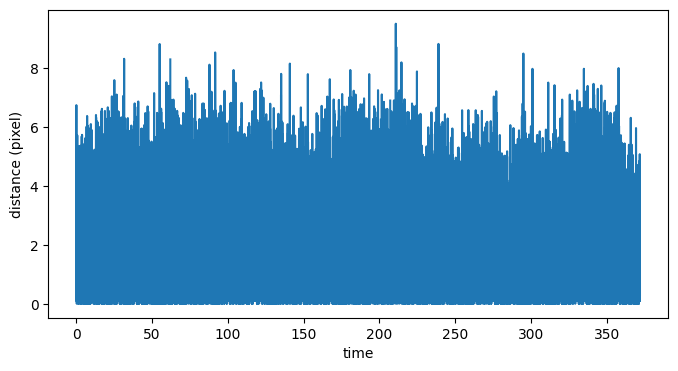

In [73]:
X_coord = coor_data_LIBRE['x_coordinate']
Y_coord = coor_data_LIBRE['y_coordinate']

t_axis_xy = (
    coor_data_LIBRE.index 
) / metadata["SamplingFrequency"]
distances = cal_diff_distance(X_coord, Y_coord)
print(distances.shape)

fig, ax= plt.subplots(figsize=(8, 4))
plt.plot(t_axis_xy[1:],
         distances)


plt.tick_params(axis='x', labelsize=10)
plt.tick_params(axis='y', labelsize=10)
plt.xlabel('time')
plt.ylabel('distance (pixel)')


(371803,)


Text(0, 0.5, 'distance (pixel)')

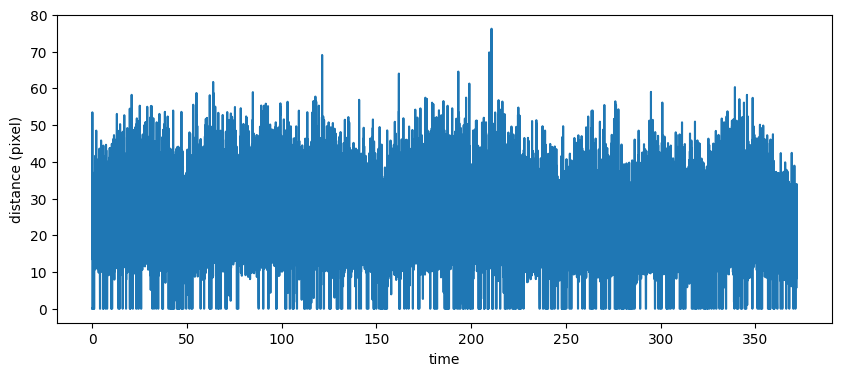

In [74]:
fig, ax= plt.subplots(figsize=(10, 4))
distances_win = cal_diff_sum_window(X_coord, Y_coord, window_size=7*2)
print(distances_win.shape)
plt.plot(t_axis_xy,
         distances_win)
plt.tick_params(axis='x', labelsize=10)
plt.tick_params(axis='y', labelsize=10)
plt.xlabel('time')
plt.ylabel('distance (pixel)')

In [75]:
# fig, ax= plt.subplots(figsize=(10, 4))
# window_size = 80
# distances_max_win = cal_max_distance_window(X_coord, Y_coord, window_size=window_size)
# print(distances_win.shape)
# plt.plot(t_axis_xy,
#          distances_max_win)
# plt.tick_params(axis='x', labelsize=10)
# plt.tick_params(axis='y', labelsize=10)
# plt.xlabel('time')
# plt.ylabel('distance (pixel)')


# save_mask_path = f'./masks_250127/subject_{subject_idx}_max_dist_win_{window_size}.mat'
# sio.savemat(save_mask_path, {'distances_max_win': distances_max_win})
# print(f'The mask file has been saved here: {save_mask_path}')
# print(len(distances_max_win[distances_max_win>60]))
# print(len(distances_max_win))

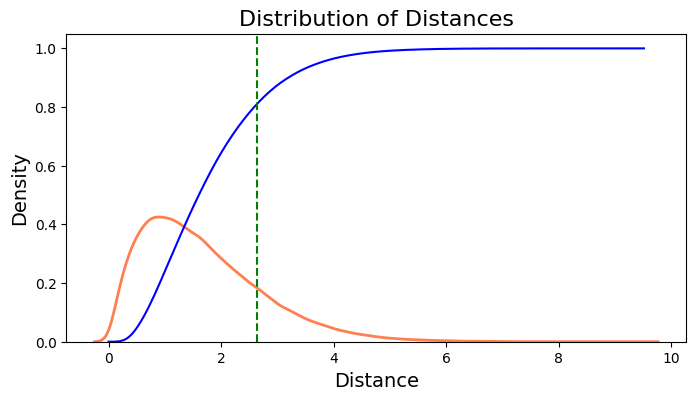

2.629262229834735


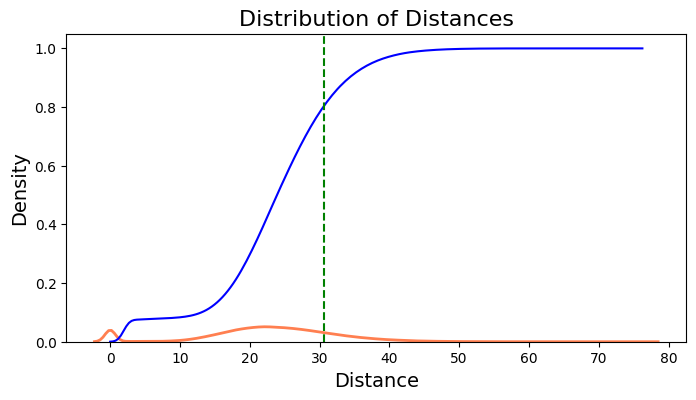

30.657537183030076


In [76]:
def plt_distribution(distances, threshold=0.8):
    import seaborn as sns

    # Filter out NaN values from the distances
    valid_distances = distances[~np.isnan(distances)]
    
    # Plot the distribution: KDE
    fig, ax= plt.subplots(figsize=(8, 4))

    kde_plot = sns.kdeplot(valid_distances, color='coral', linewidth=2, label='KDE Plot')
    # Get the x and y values from the plot (not the plot object itself)
    x_values = kde_plot.get_lines()[0].get_xdata()
    kde_values = kde_plot.get_lines()[0].get_ydata()
    # Add labels and legend
    ax.set_xlabel('Distance', fontsize=14)
    ax.set_ylabel('Density', fontsize=14)
    ax.set_title('Distribution of Distances', fontsize=16)


    # Plot the cdf values
   
    cdf_values = np.cumsum(kde_values)  # Cumulative sum
    # Normalize the CDF to range from 0 to 1
    cdf_values /= cdf_values[-1]
    x_values = np.linspace(min(valid_distances), max(valid_distances), len(cdf_values))  # Define x range
    ax.plot(x_values, cdf_values, label='CDF', color='blue')
    # Normalize the CDF to range from 0 to 1
    cdf_values /= cdf_values[-1]
    # Find the threshold value for 80% accumulation
    threshold_index = np.argmax(cdf_values >= threshold)
    threshold_value = x_values[threshold_index]
    
    ax.axvline(threshold_value, color='green', linestyle='--', label=f'80% Threshold: {threshold_value:.2f}')


    # Show plot
    plt.show()
    return threshold_value

threshold_value = plt_distribution(distances, threshold=0.8)
print(threshold_value)

threshold_value = plt_distribution(distances_win, threshold=0.8)
print(threshold_value)

# threshold_value = plt_distribution(distances_max_win, threshold=0.9)
# print(threshold_value)

In [77]:
def cal_statistics(distances):
    mean_distance = np.nanmean(distances)
    std_distance = np.nanstd(distances)
    median_distance = np.nanmedian(distances)
    min_distance = np.nanmin(distances)
    max_distance = np.nanmax(distances)
    nan_count = np.sum(np.isnan(distances))  # Count NaN values
    
    # Display the results
    print(f"Mean distance: {mean_distance:.2f}")
    print(f"Standard deviation: {std_distance:.2f}")
    print(f"Median distance: {median_distance:.2f}")
    print(f"Minimum distance: {min_distance:.2f}")
    print(f"Maximum distance: {max_distance:.2f}")
    print(f"Number of NaN values: {nan_count}")
    
cal_statistics(distances)
cal_statistics(distances_win)
# cal_statistics(distances_max_win)

Mean distance: 1.66
Standard deviation: 1.07
Median distance: 1.46
Minimum distance: 0.00
Maximum distance: 9.51
Number of NaN values: 32264
Mean distance: 22.80
Standard deviation: 9.75
Median distance: 23.26
Minimum distance: 0.00
Maximum distance: 76.26
Number of NaN values: 0


## Generate movement distance mask

In [78]:
def generate_movement_mask(distances_max_win, offset, move_criteria):
    # Generate the mask
    # the threshold should be within voxel size, or some relationship with voxel size.
    distances_max_win = distances_max_win[:]
    
    move_discard_mask = (
        (distances_max_win > move_criteria) | np.isnan(distances_max_win)
        )
    move_preserve_mask = ~(move_discard_mask)
    
    
    # Check the result
    print("Mask shape:", move_preserve_mask.shape)
    print("After appending size of offset", offset)
    preffix_mask = np.zeros(offset)
    # Concatenate the two arrays
    move_preserve_mask = np.concatenate((preffix_mask, move_preserve_mask))
    print("Mask shape:", move_preserve_mask.shape)
    
    return move_preserve_mask


# offset_first_trigger_mriStart = first trigger interval (according to log.txt) - (first mri meas - first marker)


# move_criteria = 20
# offset = mri_start_first_trigger + gap_start_dot #t1+6ms
# move_preserve_mask = generate_movement_mask(distances_max_win, offset, move_criteria)

# save_move_preserve_mask = False
# if save_move_preserve_mask:
#     save_mask_path = f'./masks_250127/subject_{subject_idx}_move_win{window_size}_crit{move_criteria}_mask.mat'
#     sio.savemat(save_mask_path, {'move_preserve_mask': move_preserve_mask})
#     print(f'The mask file has been saved here: {save_mask_path}')

## Analyzing Gaze Point Distribution Before and After Filtering

After filtering out blink-related timestamps by assigning NaN to gaze coordinates, it's important to inspect how this operation has affected the distribution of gaze points along each dimension (e.g., x_coordinate and y_coordinate).

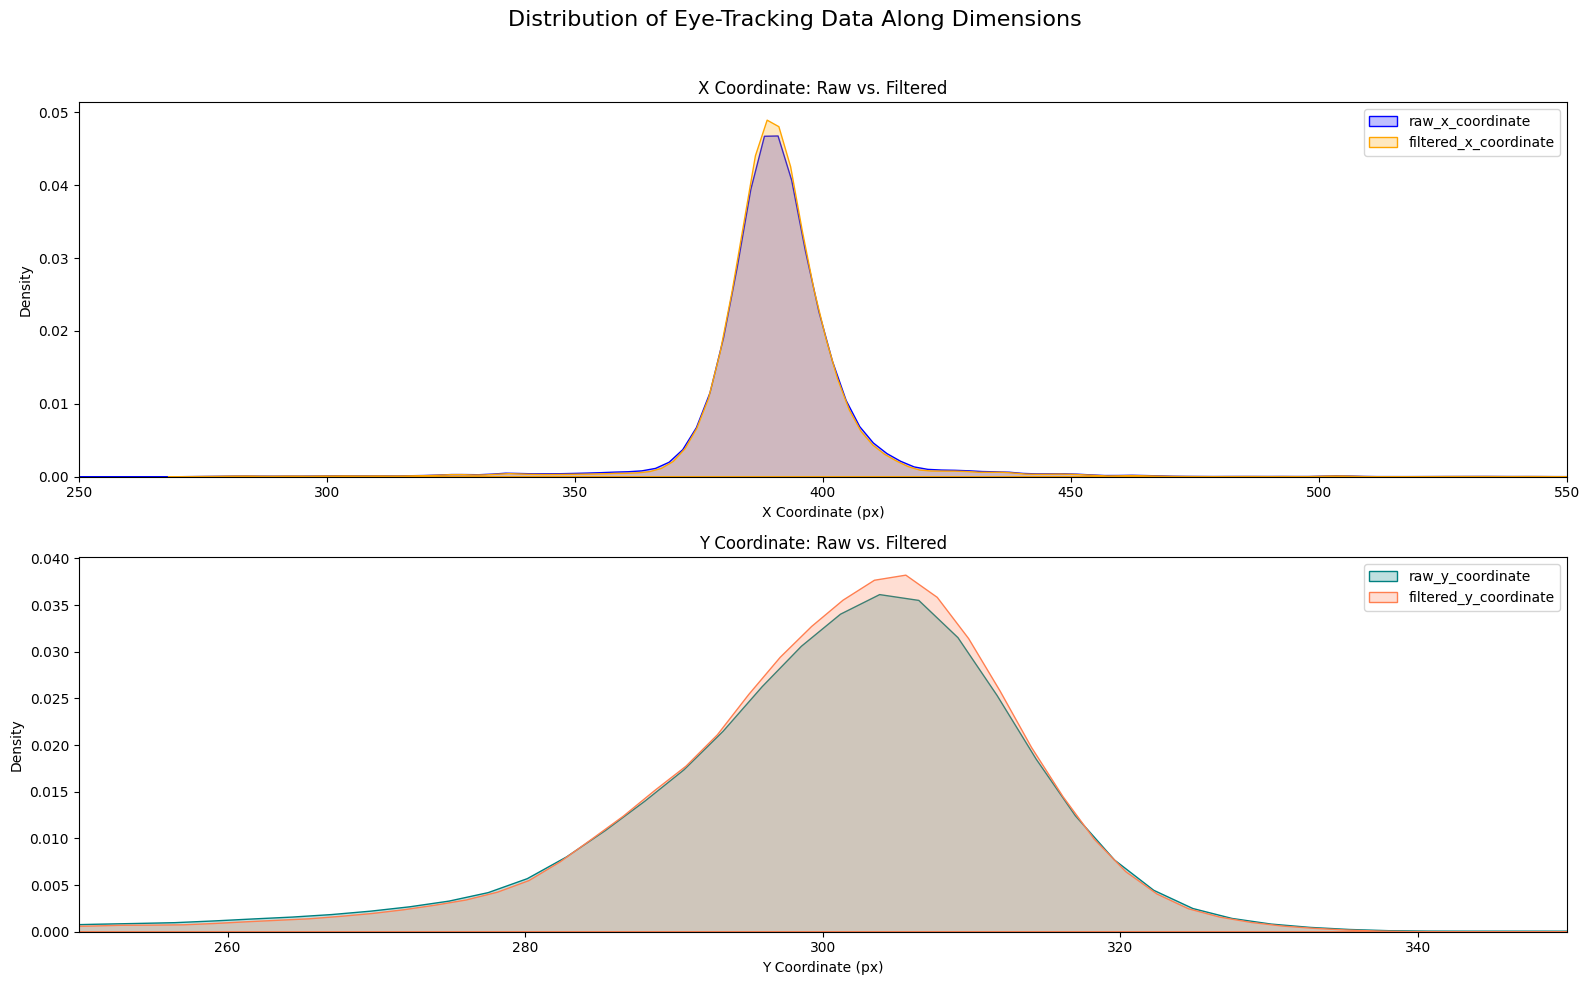

In [79]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set up the figure
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Plot KDE for eye1_x_coordinate
sns.kdeplot(coor_data_LIBRE_raw['x_coordinate'].dropna(), ax=axes[0], color='blue', fill=True, label='raw_x_coordinate')
sns.kdeplot(coor_data_LIBRE['x_coordinate'].dropna(), ax=axes[0], color='orange', fill=True, label='filtered_x_coordinate')
axes[0].set_title("X Coordinate: Raw vs. Filtered")
axes[0].set_xlabel("X Coordinate (px)")
axes[0].set_ylabel("Density")
axes[0].set_xlim((250,550))
axes[0].legend()

# Plot KDE for y coordinate
sns.kdeplot(coor_data_LIBRE_raw["y_coordinate"].dropna(), ax=axes[1], color='teal', fill=True, label='raw_y_coordinate')
sns.kdeplot(coor_data_LIBRE["y_coordinate"].dropna(), ax=axes[1], color='coral', fill=True, label='filtered_y_coordinate')
axes[1].set_title("Y Coordinate: Raw vs. Filtered")
axes[1].set_xlabel("Y Coordinate (px)")
axes[1].set_ylabel("Density")
axes[1].set_xlim((250,350))
axes[1].legend()

# Add a common title
fig.suptitle("Distribution of Eye-Tracking Data Along Dimensions", fontsize=16)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [80]:
from mask_gen import cal_mask, plot_x_y_coord, filter_XY_coord

In [81]:
def cal_stats(coor_data):
    stats_dict = {}
    X_coord = coor_data["x_coordinate"].values
    Y_coord = coor_data["y_coordinate"].values
    
    stats_dict['x_mean'] = np.nanmean(X_coord)
    stats_dict['x_median'] = np.nanmedian(X_coord)      # Median, ignoring NaNs
    stats_dict['x_std'] = np.nanstd(X_coord)        # Standard deviation
    stats_dict['x_min'] = np.nanmin(X_coord)      # Minimum value
    stats_dict['x_max'] = np.nanmax(X_coord)      # Maximum value
    # Calculate 25th, 50th (median), and 75th percentiles while ignoring NaN values
    stats_dict['x_q25'] = np.nanpercentile(X_coord, 25)  # 25th percentile
    stats_dict['x_q75'] = np.nanpercentile(X_coord, 75)  # 75th percentile

    stats_dict['y_mean'] = np.nanmean(Y_coord)
    stats_dict['y_median'] = np.nanmedian(Y_coord)      # Median, ignoring NaNs
    stats_dict['y_std'] = np.nanstd(Y_coord)        # Standard deviation
    stats_dict['y_min'] = np.nanmin(Y_coord)      # Minimum value
    stats_dict['y_max'] = np.nanmax(Y_coord)      # Maximum value
    stats_dict['y_q25'] = np.nanpercentile(Y_coord, 25)  # 25th percentile
    stats_dict['y_q75'] = np.nanpercentile(Y_coord, 75)  # 75th percentile

    return stats_dict

In [82]:
stats_dict = cal_stats(coor_data_LIBRE)
stats_dict

{'x_mean': 391.36145629380025,
 'x_median': 390.2999877929688,
 'x_std': 19.215505885939464,
 'x_min': 272.6000061035156,
 'x_max': 734.5,
 'x_q25': 385.1000061035156,
 'x_q75': 396.2000122070313,
 'y_mean': 299.9099894245908,
 'y_median': 302.1000061035156,
 'y_std': 17.219487508733334,
 'y_min': 123.9000015258789,
 'y_max': 535.7999877929688,
 'y_q25': 293.8999938964844,
 'y_q75': 308.70001220703125}

## Generate the filtered mask

## Stable Mask Notes

`ScreenAOIDefinition` describes the valid EyeLink screen coordinate AOI, usually as `[shape, [x_min, x_max, y_min, y_max]]`. 
It is useful for deriving the pixel-space screen center and bounds. It does not encode physical screen width/height, so this notebook keeps `SCREEN_WIDTH_MM` and `SCREEN_HEIGHT_MM` as explicit assumptions near the stable-mask cell.

Other metadata used here: `EyeTrackerDistance`, `SamplingFrequency`, `LoggedMessages` / `StartTimestamp`, `RecordedEye`, and the input TSV `Columns`.


To find the median coor of the point clouds
The mean position of the gaze region: [390.2999877929688, 302.1000061035156] (px)
To calculate visual angles w.r.t. points using metadata-derived screen center
371803
To calculate the displacement in both directions (mm)
371803
To generate discard masks for x and y direction...
Screen / physical assumptions used for stable mask:
{
  "EyeRadius_mm_assumption": 12.0,
  "EyeTrackerDistance_mm": 1020.0,
  "ScreenAOIDefinition": [
    "square",
    [
      0,
      800,
      0,
      600
    ]
  ],
  "screen_center_px": [
    400.0,
    300.0
  ],
  "screen_height_mm_assumption": 62.0,
  "screen_height_px": 600.0,
  "screen_width_mm_assumption": 81.3,
  "screen_width_px": 800.0,
  "x_mm_per_px": 0.101625,
  "y_mm_per_px": 0.10333333333333333
}
disp_criteria_mm: 0.04


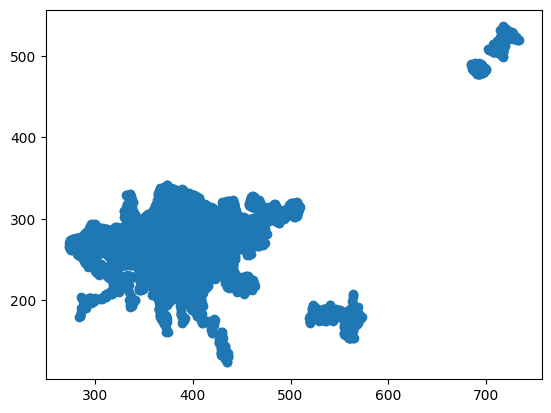

In [86]:
from mask_clean import find_mean_position, cal_disp, filter_criteria
from mask_clean import filter_XY_with_mask, visualization_func, plot_h_v_disp

# central mask
coor_data_LIBRE_ft = copy.deepcopy(coor_data_LIBRE)

X_coord_ft = coor_data_LIBRE_ft['x_coordinate']
Y_coord_ft = coor_data_LIBRE_ft['y_coordinate']

plt.scatter(X_coord_ft, Y_coord_ft)

# ScreenAOIDefinition is typically [shape, [x_min, x_max, y_min, y_max]] in screen pixels.
# It gives the valid gaze coordinate bounds and screen center in the EyeLink coordinate system.
# It does NOT by itself provide physical screen width/height in mm, so keep those as explicit assumptions.
screen_aoi = metadata.get("ScreenAOIDefinition", ["square", [0, 800, 0, 600]])[1]
screen_x_min, screen_x_max, screen_y_min, screen_y_max = [float(v) for v in screen_aoi]
screen_center_px = ((screen_x_min + screen_x_max) / 2, (screen_y_min + screen_y_max) / 2)

SCREEN_WIDTH_MM = 81.3
SCREEN_HEIGHT_MM = 62.0
EYE_RADIUS_MM = 12.0
eye_distance_m = metadata.get("EyeTrackerDistance", 1.02)
EYE_DISTANCE_MM = float(eye_distance_m) * 1000 if float(eye_distance_m) < 10 else float(eye_distance_m)
VOXEL_SIZE_MM = 0.5

def cal_angles_with_screen_metadata(X_coord, Y_coord, med_coor):
    print('To calculate visual angles w.r.t. points using metadata-derived screen center')
    screen_width_px = screen_x_max - screen_x_min
    screen_height_px = screen_y_max - screen_y_min
    if screen_width_px <= 0 or screen_height_px <= 0:
        raise ValueError(f"Invalid ScreenAOIDefinition bounds: {screen_aoi}")

    x_mm_per_px = SCREEN_WIDTH_MM / screen_width_px
    y_mm_per_px = SCREEN_HEIGHT_MM / screen_height_px

    x_hor_mm = np.where(np.isnan(X_coord), np.nan, (X_coord - screen_center_px[0]) * x_mm_per_px)
    med_x_hor_mm = (med_coor[0] - screen_center_px[0]) * x_mm_per_px
    theta_h_ = np.where(np.isnan(x_hor_mm), np.nan, np.arctan(x_hor_mm / (EYE_DISTANCE_MM + EYE_RADIUS_MM)))
    theta_h_m = np.arctan(med_x_hor_mm / (EYE_DISTANCE_MM + EYE_RADIUS_MM))

    y_ver_mm = np.where(np.isnan(Y_coord), np.nan, (Y_coord - screen_center_px[1]) * y_mm_per_px)
    med_y_ver_mm = (med_coor[1] - screen_center_px[1]) * y_mm_per_px
    rho_v_ = np.where(np.isnan(y_ver_mm), np.nan, np.arctan(y_ver_mm / (EYE_DISTANCE_MM + EYE_RADIUS_MM)))
    rho_v_m = np.arctan(med_y_ver_mm / (EYE_DISTANCE_MM + EYE_RADIUS_MM))

    screen_geometry = {
        "ScreenAOIDefinition": metadata.get("ScreenAOIDefinition"),
        "screen_center_px": screen_center_px,
        "screen_width_px": screen_width_px,
        "screen_height_px": screen_height_px,
        "screen_width_mm_assumption": SCREEN_WIDTH_MM,
        "screen_height_mm_assumption": SCREEN_HEIGHT_MM,
        "x_mm_per_px": x_mm_per_px,
        "y_mm_per_px": y_mm_per_px,
        "EyeTrackerDistance_mm": EYE_DISTANCE_MM,
        "EyeRadius_mm_assumption": EYE_RADIUS_MM,
    }
    return theta_h_, theta_h_m, rho_v_, rho_v_m, screen_geometry

med_coor_ft = find_mean_position(X_coord_ft, Y_coord_ft)
theta_h_, theta_h_m, rho_v_, rho_v_m, screen_geometry = cal_angles_with_screen_metadata(
    X_coord_ft, Y_coord_ft, med_coor_ft
)
print(len(theta_h_))
h_dis_ft, v_dis_ft = cal_disp(theta_h_, theta_h_m, rho_v_, rho_v_m)
print(len(v_dis_ft))

criteria_ratio = 0.08
disp_criteria_mm = criteria_ratio * VOXEL_SIZE_MM
discarded_x_mask, discarded_y_mask = filter_criteria(h_dis_ft, v_dis_ft, criteria_ratio=criteria_ratio)

print("Screen / physical assumptions used for stable mask:")
print(json.dumps(screen_geometry, indent=2, sort_keys=True))
print(f"disp_criteria_mm: {disp_criteria_mm}")
# preserve_mask = ~(discarded_x_mask | discarded_y_mask)


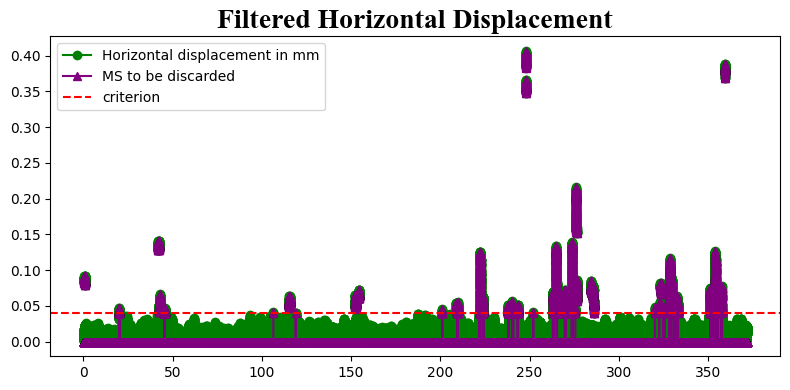

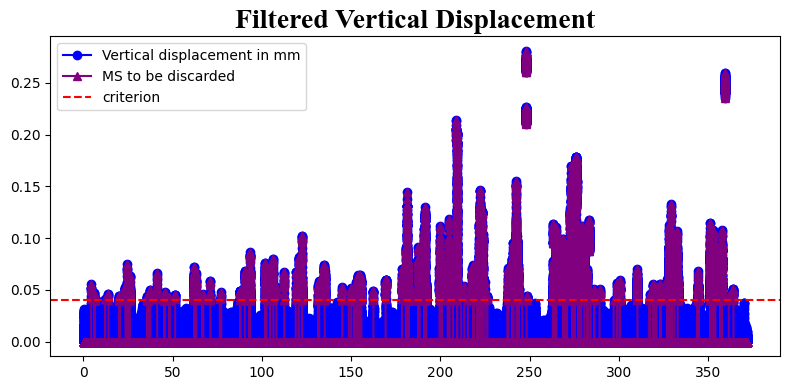

In [87]:
plot_h_v_disp(h_dis_ft, v_dis_ft, discarded_x_mask, 
              discarded_y_mask, criteria_ratio=criteria_ratio)



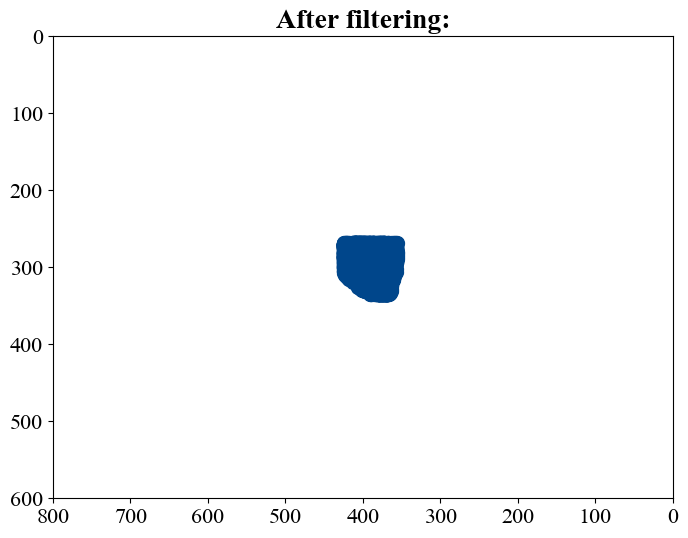

In [91]:
coor_data_ft_clean, Preserve_mask, Discard_mask = filter_XY_with_mask(coor_data_LIBRE_ft, discarded_x_mask, 
                                                                        discarded_y_mask, seq_name=None)

## Motion QC for Distance Criterion

Keep the main mask as distance-only for compatibility, but compute a local motion score to check whether adding a quick-switch criterion would materially change the mask.


In [ ]:
def compute_motion_qc(coor_data, distance_preserve_mask, window_samples=15, percentile=90):
    x = coor_data["x_coordinate"].to_numpy(dtype=float)
    y = coor_data["y_coordinate"].to_numpy(dtype=float)

    dx = np.diff(x, prepend=np.nan)
    dy = np.diff(y, prepend=np.nan)
    step_dist_px = np.sqrt(dx**2 + dy**2)
    invalid_step = np.isnan(x) | np.isnan(y) | np.isnan(dx) | np.isnan(dy)
    step_dist_px[invalid_step] = np.nan

    motion_score = pd.Series(step_dist_px).rolling(
        window=window_samples,
        center=True,
        min_periods=max(3, window_samples // 3),
    ).median().to_numpy()

    valid_motion = motion_score[~np.isnan(motion_score)]
    if len(valid_motion) == 0:
        motion_threshold_px = np.nan
        low_motion_mask = np.zeros_like(distance_preserve_mask, dtype=bool)
    else:
        motion_threshold_px = float(np.nanpercentile(valid_motion, percentile))
        low_motion_mask = (motion_score <= motion_threshold_px) & ~np.isnan(motion_score)

    distance_preserve_mask = np.asarray(distance_preserve_mask, dtype=bool)
    combined_preserve_mask = distance_preserve_mask & low_motion_mask
    diff_mask = distance_preserve_mask != combined_preserve_mask
    distance_preserved_count = int(distance_preserve_mask.sum())
    combined_preserved_count = int(combined_preserve_mask.sum())
    combined_over_distance_preserved_ratio = (
        combined_preserved_count / distance_preserved_count
        if distance_preserved_count > 0
        else np.nan
    )
    distance_preserved_removed_by_motion_ratio = (
        1.0 - combined_over_distance_preserved_ratio
        if not np.isnan(combined_over_distance_preserved_ratio)
        else np.nan
    )

    motion_qc = {
        "enabled_for_main_mask": True,
        "method": "rolling median of frame-to-frame gaze displacement in pixels",
        "window_samples": int(window_samples),
        "window_ms": float(window_samples / metadata["SamplingFrequency"] * 1000),
        "threshold_percentile": float(percentile),
        "motion_threshold_px": motion_threshold_px,
        "distance_preserved_samples": distance_preserved_count,
        "low_motion_samples": int(low_motion_mask.sum()),
        "combined_preserved_samples": combined_preserved_count,
        "distance_preserved_ratio": float(distance_preserve_mask.mean()) if len(distance_preserve_mask) else np.nan,
        "combined_preserved_ratio": float(combined_preserve_mask.mean()) if len(combined_preserve_mask) else np.nan,
        "combined_over_distance_preserved_ratio": float(combined_over_distance_preserved_ratio),
        "distance_preserved_removed_by_motion_ratio": float(distance_preserved_removed_by_motion_ratio),
        "distance_vs_motion_diff_samples": int(diff_mask.sum()),
        "distance_vs_motion_diff_ratio": float(diff_mask.mean()) if len(diff_mask) else np.nan,
    }
    return motion_score, low_motion_mask, combined_preserve_mask, motion_qc

MOTION_QC_WINDOW_SAMPLES = 15
MOTION_QC_PERCENTILE = 90
motion_score_px, low_motion_mask, Preserve_mask_distance_and_motion, motion_qc = compute_motion_qc(
    coor_data_LIBRE_ft,
    Preserve_mask,
    window_samples=MOTION_QC_WINDOW_SAMPLES,
    percentile=MOTION_QC_PERCENTILE,
)

print("Motion QC summary; final saved mask uses distance AND low-motion:")
print(json.dumps(motion_qc, indent=2, sort_keys=True))
print(
    "Motion QC within distance-preserved samples: "
    f"{motion_qc['combined_over_distance_preserved_ratio']:.4f} remain low-motion; "
    f"{motion_qc['distance_preserved_removed_by_motion_ratio']:.4f} would be removed by adding motion."
)
if motion_qc["distance_preserved_removed_by_motion_ratio"] < 0.02:
    print("Motion QC: adding low-motion criterion removes <2% of distance-preserved samples; low-motion criterion has minimal effect for this run.")
elif motion_qc["distance_preserved_removed_by_motion_ratio"] < 0.05:
    print("Motion QC: adding low-motion criterion removes <5% of distance-preserved samples; inspect plots but final combined mask is close to distance-only.")
else:
    print("WARNING: motion QC removes >=5% of distance-preserved samples; combined mask differs meaningfully from distance-only; inspect before using downstream.")

fig, ax = plt.subplots(figsize=(10, 4))
plot_t = np.arange(len(motion_score_px)) / metadata["SamplingFrequency"]
ax.plot(plot_t, motion_score_px, label="rolling motion score (px)")
if not np.isnan(motion_qc["motion_threshold_px"]):
    ax.axhline(motion_qc["motion_threshold_px"], color="r", linestyle="--", label="motion threshold")
ax.set_title("Motion QC: rolling gaze displacement")
ax.set_xlabel("time [s]")
ax.set_ylabel("pixels")
ax.legend()
plt.tight_layout()



====
x_coordinate --- statistics
Mean distance: 391.36
Standard deviation: 19.22
Median distance: 390.30
Minimum distance: 272.60
Maximum distance: 734.50
Number of NaN values: 31903

====
y_coordinate --- statistics
Mean distance: 299.91
Standard deviation: 17.22
Median distance: 302.10
Minimum distance: 123.90
Maximum distance: 535.80
Number of NaN values: 31903


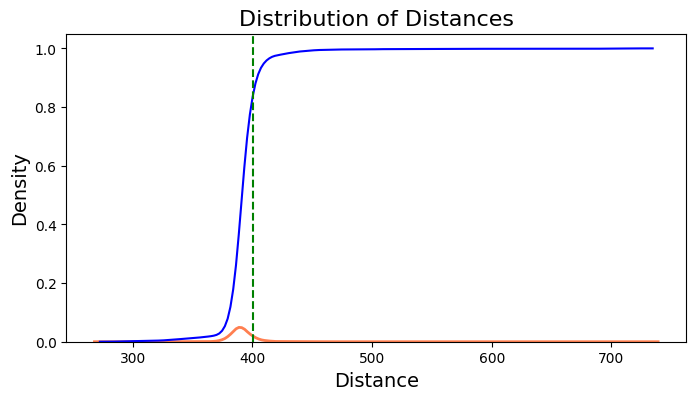

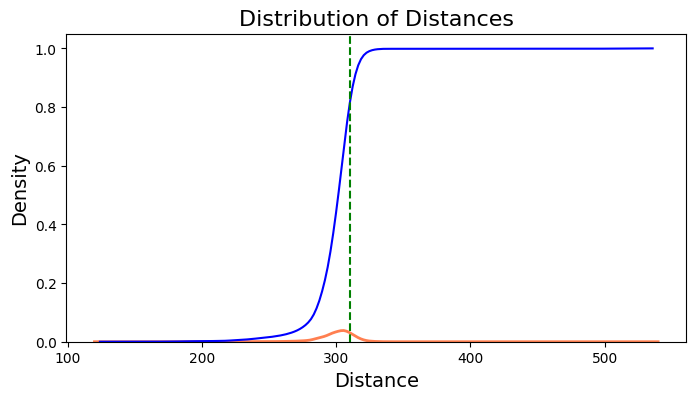

In [92]:
print('\n====\nx_coordinate --- statistics')
cal_statistics(coor_data_LIBRE_ft['x_coordinate'])
print('\n====\ny_coordinate --- statistics')
cal_statistics(coor_data_LIBRE_ft['y_coordinate'])
threshold_value_x = plt_distribution(coor_data_LIBRE_ft['x_coordinate'], threshold=0.8)
threshold_value_y = plt_distribution(coor_data_LIBRE_ft['y_coordinate'], threshold=0.8)

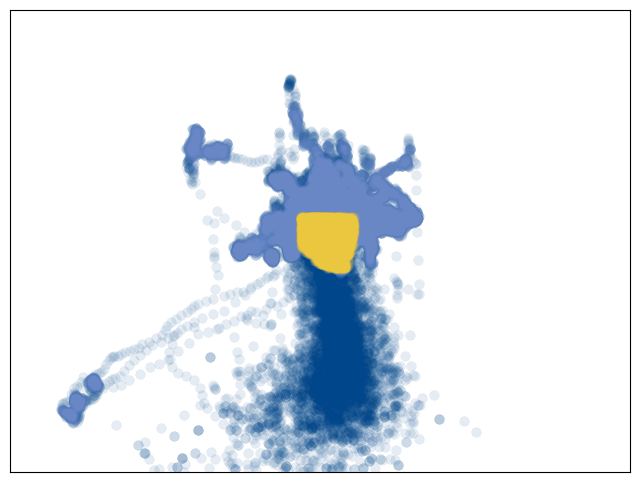

In [93]:

# Visualization of filtered coor data LIBRE

visualization_func(fig_title='Before vs After (filtering)', 
                   coor_data_raw = coor_data_LIBRE_raw, coor_data=coor_data_LIBRE_ft, coor_data_clean=coor_data_ft_clean)

output_figs_dir = Path("./output_figs/"+subject_idx)
output_figs_dir.mkdir(parents=True, exist_ok=True)

plt.savefig(Path(output_figs_dir/"2_0_mreye_et_filtering.pdf"), dpi=300, bbox_inches='tight')

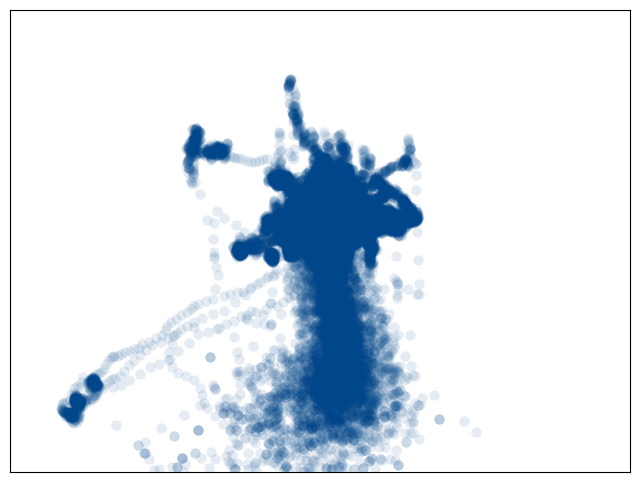

In [94]:
visualization_func(fig_title='Before vs After (filtering)', 
                   coor_data_raw = coor_data_LIBRE_raw, coor_data=0, coor_data_clean=0)

plt.savefig(Path(output_figs_dir/"2_0_mreye_et_raw.pdf"), dpi=300, bbox_inches='tight')

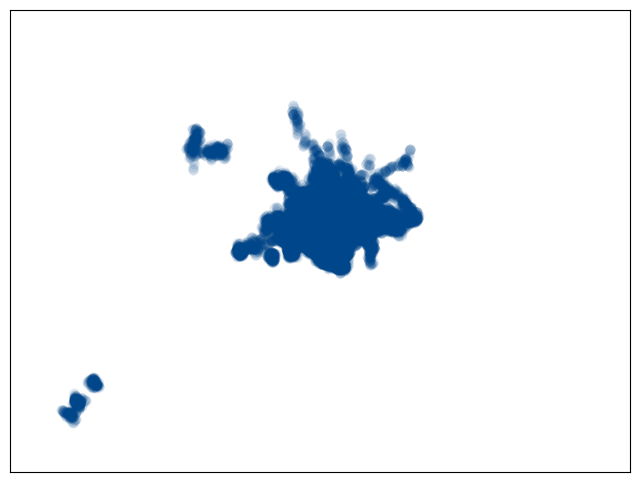

In [95]:
visualization_func(fig_title='Before vs After (filtering)', 
                   coor_data_raw = coor_data_LIBRE_ft, coor_data=0, coor_data_clean=0)

plt.savefig(Path(output_figs_dir/"2_0_mreye_et_nomo.pdf"), dpi=300, bbox_inches='tight')

In [ ]:
# Final mask now uses both criteria: near median/center AND low local motion.
Distance_only_mask = np.asarray(Preserve_mask, dtype=bool)
Final_preserve_mask = np.asarray(Preserve_mask_distance_and_motion, dtype=bool)

count_distance_only = int(np.sum(Distance_only_mask))
count_true = int(np.sum(Final_preserve_mask))
preserved_ratio_distance_only = count_distance_only / len(Distance_only_mask) if len(Distance_only_mask) else np.nan
preserved_ratio_before_offset = count_true / len(Final_preserve_mask) if len(Final_preserve_mask) else np.nan
print(f'Distance-only preserved #ET samples: {count_distance_only}')
print(f'Final distance+motion preserved #ET samples: {count_true}')
print(f'Distance-only preserved ratio before offset: {preserved_ratio_distance_only:.4f}')
print(f'Final preserved ratio before offset: {preserved_ratio_before_offset:.4f}')
print(f'Size of mask before concatenation: {len(Final_preserve_mask)}')

if offset < 0:
    raise ValueError(f"Negative offset is not valid for mask padding: {offset}")
if offset > int(np.round(twix_duration)):
    raise ValueError(f"Offset {offset} exceeds twix_duration {twix_duration}")

preffix_mask = np.zeros(offset, dtype=np.uint8)
Final_preserve_mask_uint8 = Final_preserve_mask.astype(np.uint8)
Preserve_mask_cat = np.concatenate((preffix_mask, Final_preserve_mask_uint8)).astype(np.uint8)
print(f'Size of final mask after concatenation: {len(Preserve_mask_cat)}')
print(f'twix_duration: {twix_duration}')
assert len(Preserve_mask_cat) == int(np.round(twix_duration))

preserved_ratio_after_offset = float(np.mean(Preserve_mask_cat)) if len(Preserve_mask_cat) else np.nan
if preserved_ratio_before_offset < 0.2:
    print(f"WARNING: final preserved ratio before offset is low ({preserved_ratio_before_offset:.4f}); inspect stable mask manually.")
if preserved_ratio_before_offset > 0.95:
    print(f"WARNING: final preserved ratio before offset is very high ({preserved_ratio_before_offset:.4f}); criteria may be too loose.")

# Save the final Preserve_mask
import os
import scipy.io as sio
save_mask = True

if save_mask:
    mask_name = f'subject_{subject_idx}_mask_clean_{criteria_ratio}.mat'
    sidecar_name = f'subject_{subject_idx}_mask_clean_{criteria_ratio}_metadata.json'

    SAVE_PATH = './masks/'+subject_idx+'/'

    # Create the folder if it doesn't exist
    os.makedirs(SAVE_PATH, exist_ok=True)
    mask_file = SAVE_PATH + mask_name
    sidecar_file = SAVE_PATH + sidecar_name

    stable_mask_metadata = {
        "subject_idx": subject_idx,
        "source_tsv": str(recording_file),
        "mode": mode,
        "T_idx": int(T_idx),
        "final_mask_method": "distance_and_low_motion",
        "distance_only_used_for_qc_only": True,
        "twix_duration_ms": float(twix_duration),
        "offset_ms": int(offset),
        "libre_samples": int(libre_samples),
        "criteria_ratio": float(criteria_ratio),
        "motion_window_samples": int(MOTION_QC_WINDOW_SAMPLES),
        "motion_percentile": float(MOTION_QC_PERCENTILE),
        "voxel_size_mm": float(VOXEL_SIZE_MM),
        "disp_criteria_mm": float(disp_criteria_mm),
        "distance_only_preserved_samples_before_offset": int(count_distance_only),
        "final_preserved_samples_before_offset": int(count_true),
        "mask_samples_before_offset": int(len(Final_preserve_mask)),
        "mask_samples_after_offset": int(len(Preserve_mask_cat)),
        "distance_only_preserved_ratio_before_offset": float(preserved_ratio_distance_only),
        "final_preserved_ratio_before_offset": float(preserved_ratio_before_offset),
        "final_preserved_ratio_after_offset": float(preserved_ratio_after_offset),
        "screen_geometry": screen_geometry,
        "input_sanity": s2_input_sanity,
        "event_overlap_summary": event_overlap_summary,
        "motion_qc": motion_qc,
    }

    # Save final distance+low-motion mask as uint8 to avoid ambiguous float masks in MATLAB.
    sio.savemat(mask_file, {'array': Preserve_mask_cat})

    SAVE_DISTANCE_ONLY_MASK = False
    if SAVE_DISTANCE_ONLY_MASK:
        distance_only_mask_name = f'subject_{subject_idx}_mask_clean_{criteria_ratio}_distance_only.mat'
        distance_only_mask_file = SAVE_PATH + distance_only_mask_name
        distance_only_mask_cat = np.concatenate((preffix_mask, Distance_only_mask.astype(np.uint8))).astype(np.uint8)
        assert len(distance_only_mask_cat) == int(np.round(twix_duration))
        sio.savemat(distance_only_mask_file, {'array': distance_only_mask_cat})
        print(f'The optional distance-only mask has been saved here: {distance_only_mask_file}')

    # Keep a copy next to the mask and also merge the same metadata into the ET JSON sidecar.
    Path(sidecar_file).write_text(json.dumps(stable_mask_metadata, indent=2, sort_keys=True) + "\n")
    if metadata_file.exists():
        et_metadata = json.loads(metadata_file.read_text())
        et_metadata["S2StableMask"] = stable_mask_metadata
        metadata_file.write_text(json.dumps(et_metadata, indent=2, sort_keys=True) + "\n")
        print(f"Merged S2 stable mask metadata into ET JSON sidecar: {metadata_file}")
    print(f'The final distance+motion mask file has been saved here: {mask_file}')
    print(f'The mask metadata sidecar has been saved here: {sidecar_file}')


In [97]:
save_Discard_mask = False

if save_Discard_mask:
    Discard_mask = ~Preserve_mask
    count_true = np.sum(Discard_mask)
    print(count_true)
    preffix_mask = np.ones(offset)
    # Concatenate the two arrays
    Discard_mask = np.concatenate((preffix_mask, Discard_mask))
    print(f'Size of mask after concatenation: {len(Discard_mask)}')
    # Save the Preserve_mask
    import os
    import scipy.io as sio
    
    mask_name = f'subject_{subject_idx}_discard_mask_{criteria_ratio}.mat'
    
    SAVE_PATH = './masks/'+subject_idx+'/'

    # Create the folder if it doesn't exist
    os.makedirs(SAVE_PATH, exist_ok=True)
    mask_file = SAVE_PATH + mask_name

    # Save array to a .mat file
    sio.savemat(mask_file, {'array': Discard_mask})
    print(f'The mask file has been saved here: {mask_file}')

Organize the mask files to the HPC

In [98]:
import subprocess
from pathlib import Path

RUN_RSYNC = False

if RUN_RSYNC:
    src = Path("./masks/" + subject_idx)
    dst = Path(
        "/Volumes/FS_PROJETS/MatTechLab/yiwei.jia/"
        "recon_results/" + RECON_FOLDER_DATE + "/" + subject_idx + "_recon/T1_LIBRE_Binning/et_masks"
    )

    # Ensure destination exists
    dst.mkdir(parents=True, exist_ok=True)

    cmd = [
        "rsync",
        "-av",
        f"{src}/",      # trailing slash is IMPORTANT
        f"{dst}/",
    ]

    print("Running:", " ".join(cmd))
    subprocess.run(cmd, check=True)

    dst_local = Path(
        "/Users/cag/Documents/Dataset/"
        "recon_results/" + RECON_FOLDER_DATE + "/" + subject_idx + "_recon/T1_LIBRE_Binning/et_masks"
    )

    # Ensure destination exists
    dst_local.mkdir(parents=True, exist_ok=True)

    cmd = [
        "rsync",
        "-av",
        f"{src}/",      # trailing slash is IMPORTANT
        f"{dst_local}/",
    ]
    print("Running:", " ".join(cmd))
    subprocess.run(cmd, check=True)
else:
    print("RUN_RSYNC is False; stable-mask outputs stay local.")


RUN_RSYNC is False; stable-mask outputs stay local.
